# Differentially Private Federated Learning
# Opacus + Flower + PyTorch + FedAvg

## 1. Install Opacus and Import Libraries

In [3]:
# Install required libraries when running in a fresh environment.
%pip install -q opacus "flwr[simulation]" torch torchvision torchaudio scikit-learn pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import importlib.util
import os
import random
import warnings

import flwr as fl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from collections import OrderedDict
from flwr.common import ndarrays_to_parameters
from opacus import PrivacyEngine
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore")

In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", DEVICE)

Using Device: cpu


## 2. Configuration

In [6]:
NUM_CLIENTS = 4
NUM_ROUNDS = 10
LOCAL_EPOCHS = 5
BATCH_SIZE = 32
LEARNING_RATE = 0.001
TEST_SIZE = 0.20
RANDOM_STATE = 42

NOISE_MULTIPLIER = 1.0
MAX_GRAD_NORM = 1.0
DELTA = 1e-5

CLIENT_DATA_DIR = "data/clients"
CLIENT_FILES = [
    "hospital_a.csv",
    "hospital_b.csv",
    "hospital_c.csv",
    "hospital_d.csv",
]

RESULTS_DIR = "results"
MODEL_SAVE_PATH = "models"
DP_MODEL_PATH = os.path.join(MODEL_SAVE_PATH, "dp_global_model.pth")

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

## 3. Load Prepared Client Datasets

In [7]:
client_paths = [os.path.join(CLIENT_DATA_DIR, filename) for filename in CLIENT_FILES]

client_datasets = []
for path in client_paths:
    df = pd.read_csv(path)
    client_datasets.append(df)
    print(f"{os.path.basename(path)}: {df.shape}")

summary_path = os.path.join(RESULTS_DIR, "client_summary.csv")
if os.path.exists(summary_path):
    client_summary = pd.read_csv(summary_path)
    display(client_summary)

hospital_a.csv: (303, 14)
hospital_b.csv: (294, 14)
hospital_c.csv: (123, 14)
hospital_d.csv: (200, 14)


,Client,Rows,Disease %
0,hospital_a.csv,303,45.87
1,hospital_b.csv,294,36.05
2,hospital_c.csv,123,93.50
3,hospital_d.csv,200,74.50


## 4. Reusable Data Loader

In [8]:
class HeartDiseaseDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_loader(X, y, batch_size=BATCH_SIZE, shuffle=False):
    dataset = HeartDiseaseDataset(X, y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def prepare_client_loaders(client_frames, feature_columns, target_column="target"):
    client_splits = []
    all_train_features = []

    for client_name, df in zip(CLIENT_FILES, client_frames):
        X = df[feature_columns].astype(np.float32).values
        y = df[target_column].astype(np.float32).values

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
            stratify=y,
        )

        client_splits.append(
            {
                "client_name": client_name.replace(".csv", ""),
                "X_train": X_train,
                "X_test": X_test,
                "y_train": y_train,
                "y_test": y_test,
            }
        )
        all_train_features.append(X_train)

    scaler = StandardScaler()
    scaler.fit(np.vstack(all_train_features))

    client_loaders = []
    for split in client_splits:
        X_train_scaled = scaler.transform(split["X_train"]).astype(np.float32)
        X_test_scaled = scaler.transform(split["X_test"]).astype(np.float32)

        client_loaders.append(
            {
                "client_name": split["client_name"],
                "train_loader": make_loader(X_train_scaled, split["y_train"], shuffle=True),
                "test_loader": make_loader(X_test_scaled, split["y_test"], shuffle=False),
                "num_train_examples": len(split["y_train"]),
                "num_test_examples": len(split["y_test"]),
            }
        )

    return client_loaders, scaler

In [9]:
target_column = "target"
feature_columns = [col for col in client_datasets[0].columns if col != target_column]
input_dim = len(feature_columns)

client_loaders, scaler = prepare_client_loaders(
    client_datasets,
    feature_columns=feature_columns,
    target_column=target_column,
)

print(f"Input features: {input_dim}")
for loader_info in client_loaders:
    print(
        f"{loader_info['client_name']}: "
        f"train={loader_info['num_train_examples']}, "
        f"test={loader_info['num_test_examples']}"
    )

Input features: 13
hospital_a: train=242, test=61
hospital_b: train=235, test=59
hospital_c: train=98, test=25
hospital_d: train=160, test=40


## 5. Reuse HeartDiseaseNet

In [10]:
class HeartDiseaseNet(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(num_features, 32),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.network(x)


global_model = HeartDiseaseNet(input_dim).to(DEVICE)
print(global_model)

HeartDiseaseNet(
  (network): Sequential(
    (0): Linear(in_features=13, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=1, bias=True)
  )
)


## 6. Model Parameters and Evaluation Helpers

In [11]:
def unwrap_private_model(model):
    return model._module if hasattr(model, "_module") else model


def get_model_parameters(model):
    base_model = unwrap_private_model(model)
    return [value.detach().cpu().numpy().copy() for value in base_model.state_dict().values()]


def set_model_parameters(model, parameters):
    base_model = unwrap_private_model(model)
    params_dict = zip(base_model.state_dict().keys(), parameters)
    state_dict = OrderedDict(
        {
            key: torch.tensor(value, dtype=base_model.state_dict()[key].dtype)
            for key, value in params_dict
        }
    )
    base_model.load_state_dict(state_dict, strict=True)


def predict(model, loader):
    model.eval()
    probabilities = []
    labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits = model(X_batch.to(DEVICE))
            probs = torch.sigmoid(logits).cpu().numpy().ravel()
            probabilities.extend(probs)
            labels.extend(y_batch.numpy().ravel())

    return np.array(labels), np.array(probabilities)


def evaluate_on_loader(model, loader):
    y_true, y_prob = predict(model, loader)
    y_pred = (y_prob >= 0.5).astype(int)
    criterion = nn.BCEWithLogitsLoss()

    loss_values = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits = model(X_batch.to(DEVICE))
            loss = criterion(logits, y_batch.to(DEVICE))
            loss_values.append(loss.item() * X_batch.size(0))

    return {
        "loss": sum(loss_values) / len(loader.dataset),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
    }


def evaluate_global_model(model, loaders):
    y_true_parts = []
    y_prob_parts = []

    for loader_info in loaders:
        y_true, y_prob = predict(model, loader_info["test_loader"])
        y_true_parts.append(y_true)
        y_prob_parts.append(y_prob)

    y_true = np.concatenate(y_true_parts)
    y_prob = np.concatenate(y_prob_parts)
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        "classification_report": classification_report(y_true, y_pred, zero_division=0),
    }

## 7. Attach PrivacyEngine and Train Local DP Model

In [12]:
def train_local_dp_model(model, train_loader, privacy_engine, epochs=LOCAL_EPOCHS):
    model.train()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    private_model, private_optimizer, private_loader = privacy_engine.make_private(
        module=model,
        optimizer=optimizer,
        data_loader=train_loader,
        noise_multiplier=NOISE_MULTIPLIER,
        max_grad_norm=MAX_GRAD_NORM,
    )

    total_loss = 0.0
    total_examples = 0

    for _ in range(epochs):
        for X_batch, y_batch in private_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            private_optimizer.zero_grad()
            logits = private_model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            private_optimizer.step()

            batch_size = X_batch.size(0)
            total_loss += loss.item() * batch_size
            total_examples += batch_size

    epsilon = privacy_engine.get_epsilon(delta=DELTA)
    return private_model, total_loss / total_examples, epsilon

## 8. Flower NumPyClient with DP Local Training

In [13]:
class DPHeartDiseaseClient(fl.client.NumPyClient):
    def __init__(self, client_id, train_loader, test_loader):
        self.client_id = client_id
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.privacy_engine = PrivacyEngine()

    def get_parameters(self, config):
        model = HeartDiseaseNet(input_dim).to(DEVICE)
        return get_model_parameters(model)

    def fit(self, parameters, config):
        model = HeartDiseaseNet(input_dim).to(DEVICE)
        set_model_parameters(model, parameters)

        private_model, loss, epsilon = train_local_dp_model(
            model,
            self.train_loader,
            privacy_engine=self.privacy_engine,
            epochs=int(config.get("local_epochs", LOCAL_EPOCHS)),
        )

        return (
            get_model_parameters(private_model),
            len(self.train_loader.dataset),
            {"loss": float(loss), "epsilon": float(epsilon)},
        )

    def evaluate(self, parameters, config):
        model = HeartDiseaseNet(input_dim).to(DEVICE)
        set_model_parameters(model, parameters)
        metrics = evaluate_on_loader(model, self.test_loader)
        return (
            float(metrics["loss"]),
            len(self.test_loader.dataset),
            {
                "accuracy": float(metrics["accuracy"]),
                "precision": float(metrics["precision"]),
                "recall": float(metrics["recall"]),
                "f1": float(metrics["f1"]),
                "roc_auc": float(metrics["roc_auc"]),
            },
        )


def client_fn(cid):
    loader_info = client_loaders[int(cid)]
    return DPHeartDiseaseClient(
        client_id=cid,
        train_loader=loader_info["train_loader"],
        test_loader=loader_info["test_loader"],
    ).to_client()

## 9. Configure FedAvg Server

In [14]:
dp_history = []


def weighted_average(metrics):
    total_examples = sum(num_examples for num_examples, _ in metrics)
    return {
        key: sum(num_examples * metric_values[key] for num_examples, metric_values in metrics) / total_examples
        for key in metrics[0][1]
    }


def average_parameters(client_results):
    total_examples = sum(num_examples for _, num_examples in client_results)
    averaged_parameters = []

    for parameter_group in zip(*(parameters for parameters, _ in client_results)):
        averaged_parameters.append(
            sum(parameter * num_examples for parameter, (_, num_examples) in zip(parameter_group, client_results))
            / total_examples
        )

    return averaged_parameters


def fit_config(server_round):
    return {"local_epochs": LOCAL_EPOCHS}


def server_evaluate(server_round, parameters, config):
    set_model_parameters(global_model, parameters)
    metrics = evaluate_global_model(global_model, client_loaders)
    loss = 1.0 - metrics["accuracy"]

    if server_round > 0:
        dp_history.append(
            {
                "round": server_round,
                "loss": loss,
                "accuracy": metrics["accuracy"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1"],
                "roc_auc": metrics["roc_auc"],
            }
        )

    return loss, {
        "accuracy": float(metrics["accuracy"]),
        "precision": float(metrics["precision"]),
        "recall": float(metrics["recall"]),
        "f1": float(metrics["f1"]),
        "roc_auc": float(metrics["roc_auc"]),
    }


initial_model_parameters = get_model_parameters(global_model)
initial_parameters = ndarrays_to_parameters(initial_model_parameters)

strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=NUM_CLIENTS,
    min_evaluate_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    initial_parameters=initial_parameters,
    on_fit_config_fn=fit_config,
    evaluate_fn=server_evaluate,
    fit_metrics_aggregation_fn=weighted_average,
    evaluate_metrics_aggregation_fn=weighted_average,
)

## 10. Run Flower FedAvg Simulation

In [15]:
round_privacy = []

if importlib.util.find_spec("ray") is not None:
    simulation_history = fl.simulation.start_simulation(
        client_fn=client_fn,
        num_clients=NUM_CLIENTS,
        config=fl.server.ServerConfig(num_rounds=NUM_ROUNDS),
        strategy=strategy,
        client_resources={"num_cpus": 1, "num_gpus": 0.0},
    )
else:
    print("Ray is not installed, so running an in-process FedAvg simulation with Flower NumPyClients.")
    global_parameters = initial_model_parameters
    dp_clients = [
        DPHeartDiseaseClient(
            client_id=str(cid),
            train_loader=client_loaders[cid]["train_loader"],
            test_loader=client_loaders[cid]["test_loader"],
        )
        for cid in range(NUM_CLIENTS)
    ]

    for server_round in range(1, NUM_ROUNDS + 1):
        client_results = []
        client_metrics = []

        for cid in range(NUM_CLIENTS):
            updated_parameters, num_examples, fit_metrics = dp_clients[cid].fit(
                global_parameters,
                fit_config(server_round),
            )
            client_results.append((updated_parameters, num_examples))
            client_metrics.append((num_examples, fit_metrics))

        global_parameters = average_parameters(client_results)
        server_loss, server_metrics = server_evaluate(server_round, global_parameters, {})
        privacy_metrics = weighted_average(client_metrics)
        round_privacy.append(
            {
                "round": server_round,
                "epsilon": privacy_metrics["epsilon"],
                "client_train_loss": privacy_metrics["loss"],
                "delta": DELTA,
                "noise_multiplier": NOISE_MULTIPLIER,
                "max_grad_norm": MAX_GRAD_NORM,
            }
        )

        print(
            f"Round {server_round:02d} | "
            f"loss={server_loss:.4f} | "
            f"acc={server_metrics['accuracy']:.4f} | "
            f"f1={server_metrics['f1']:.4f} | "
            f"auc={server_metrics['roc_auc']:.4f} | "
            f"epsilon={privacy_metrics['epsilon']:.4f}"
        )

dp_history_df = pd.DataFrame(dp_history)
privacy_df = pd.DataFrame(round_privacy)
display(dp_history_df)
display(privacy_df.tail())

Ray is not installed, so running an in-process FedAvg simulation with Flower NumPyClients.
Round 01 | loss=0.3730 | acc=0.6270 | f1=0.6057 | auc=0.6552 | epsilon=6.4329
Round 02 | loss=0.3243 | acc=0.6757 | f1=0.6512 | auc=0.7730 | epsilon=8.8787
Round 03 | loss=0.2865 | acc=0.7135 | f1=0.6936 | auc=0.8272 | epsilon=10.8883
Round 04 | loss=0.2541 | acc=0.7459 | f1=0.7345 | auc=0.8525 | epsilon=12.6708
Round 05 | loss=0.2270 | acc=0.7730 | f1=0.7692 | auc=0.8672 | epsilon=14.3075
Round 06 | loss=0.2054 | acc=0.7946 | f1=0.8000 | auc=0.8742 | epsilon=15.8403
Round 07 | loss=0.2108 | acc=0.7892 | f1=0.8000 | auc=0.8785 | epsilon=17.2942
Round 08 | loss=0.2054 | acc=0.7946 | f1=0.8081 | auc=0.8816 | epsilon=18.6855
Round 09 | loss=0.1946 | acc=0.8054 | f1=0.8200 | auc=0.8833 | epsilon=20.0255
Round 10 | loss=0.1784 | acc=0.8216 | f1=0.8374 | auc=0.8852 | epsilon=21.3225


,round,loss,accuracy,precision,recall,f1,roc_auc
0,1,0.372973,0.627027,0.726027,0.519608,0.605714,0.655209
1,2,0.324324,0.675676,0.800000,0.549020,0.651163,0.772974
2,3,0.286486,0.713514,0.845070,0.588235,0.693642,0.827191
3,4,0.254054,0.745946,0.866667,0.637255,0.734463,0.852469
4,5,0.227027,0.772973,0.875000,0.686275,0.769231,0.867234
5,6,0.205405,0.794595,0.863636,0.745098,0.800000,0.874203
6,7,0.210811,0.789189,0.838710,0.764706,0.800000,0.878455
7,8,0.205405,0.794595,0.833333,0.784314,0.808081,0.881644
8,9,0.194595,0.805405,0.836735,0.803922,0.820000,0.883298
9,10,0.178378,0.821622,0.841584,0.833333,0.837438,0.885188


,round,epsilon,client_train_loss,delta,noise_multiplier,max_grad_norm
5,6,15.840327,0.615250,0.00001,1.0,1.0
6,7,17.294231,0.594817,0.00001,1.0,1.0
7,8,18.685512,0.572274,0.00001,1.0,1.0
8,9,20.025519,0.541847,0.00001,1.0,1.0
9,10,21.322532,0.524738,0.00001,1.0,1.0


## 11. Evaluate and Save DP Global Model

In [16]:
dp_final_metrics = evaluate_global_model(global_model, client_loaders)
final_epsilon = privacy_df["epsilon"].iloc[-1] if not privacy_df.empty else np.nan

print("Final Differentially Private Federated Model Performance")
print(f"Accuracy : {dp_final_metrics['accuracy']:.4f}")
print(f"Precision: {dp_final_metrics['precision']:.4f}")
print(f"Recall   : {dp_final_metrics['recall']:.4f}")
print(f"F1-score : {dp_final_metrics['f1']:.4f}")
print(f"ROC-AUC  : {dp_final_metrics['roc_auc']:.4f}")
print(f"Epsilon  : {final_epsilon:.4f} at delta={DELTA}")
print("\nConfusion Matrix:")
print(dp_final_metrics["confusion_matrix"])
print("\nClassification Report:")
print(dp_final_metrics["classification_report"])

Final Differentially Private Federated Model Performance
Accuracy : 0.8216
Precision: 0.8416
Recall   : 0.8333
F1-score : 0.8374
ROC-AUC  : 0.8852
Epsilon  : 21.3225 at delta=1e-05

Confusion Matrix:
[[67 16]
 [17 85]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.80      0.81      0.80        83
         1.0       0.84      0.83      0.84       102

    accuracy                           0.82       185
   macro avg       0.82      0.82      0.82       185
weighted avg       0.82      0.82      0.82       185



In [17]:
dp_results_path = os.path.join(RESULTS_DIR, "dp_federated_results.csv")
dp_history_path = os.path.join(RESULTS_DIR, "dp_federated_training_history.csv")
dp_privacy_path = os.path.join(RESULTS_DIR, "dp_privacy_history.csv")

dp_summary_df = pd.DataFrame(
    [
        {
            "model": "DP Flower FedAvg HeartDiseaseNet",
            "rounds": NUM_ROUNDS,
            "local_epochs": LOCAL_EPOCHS,
            "noise_multiplier": NOISE_MULTIPLIER,
            "max_grad_norm": MAX_GRAD_NORM,
            "delta": DELTA,
            "epsilon": final_epsilon,
            "accuracy": dp_final_metrics["accuracy"],
            "precision": dp_final_metrics["precision"],
            "recall": dp_final_metrics["recall"],
            "f1": dp_final_metrics["f1"],
            "roc_auc": dp_final_metrics["roc_auc"],
        }
    ]
)

dp_history_df.to_csv(dp_history_path, index=False)
privacy_df.to_csv(dp_privacy_path, index=False)
dp_summary_df.to_csv(dp_results_path, index=False)

torch.save(
    {
        "model_state_dict": global_model.state_dict(),
        "feature_columns": feature_columns,
        "scaler_mean": scaler.mean_,
        "scaler_scale": scaler.scale_,
        "config": {
            "num_rounds": NUM_ROUNDS,
            "local_epochs": LOCAL_EPOCHS,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "noise_multiplier": NOISE_MULTIPLIER,
            "max_grad_norm": MAX_GRAD_NORM,
            "delta": DELTA,
            "epsilon": final_epsilon,
        },
        "metrics": dp_summary_df.iloc[0].to_dict(),
    },
    DP_MODEL_PATH,
)

print(f"Saved DP summary: {dp_results_path}")
print(f"Saved DP history: {dp_history_path}")
print(f"Saved DP privacy history: {dp_privacy_path}")
print(f"Saved DP model: {DP_MODEL_PATH}")
dp_summary_df

Saved DP summary: results\dp_federated_results.csv
Saved DP history: results\dp_federated_training_history.csv
Saved DP privacy history: results\dp_privacy_history.csv
Saved DP model: models\dp_global_model.pth


,model,rounds,local_epochs,noise_multiplier,max_grad_norm,delta,epsilon,accuracy,precision,recall,f1,roc_auc
0,DP Flower FedAvg HeartDiseaseNet,10,5,1.0,1.0,0.00001,21.322532,0.821622,0.841584,0.833333,0.837438,0.885188


## 12. Compare DP and Non-DP Federated Models

In [18]:
non_dp_results_path = os.path.join(RESULTS_DIR, "federated_results.csv")

if os.path.exists(non_dp_results_path):
    non_dp_summary = pd.read_csv(non_dp_results_path)
    non_dp_row = non_dp_summary.iloc[0].to_dict()

    comparison_df = pd.DataFrame(
        [
            {
                "model": "Non-DP Federated",
                "accuracy": non_dp_row["accuracy"],
                "precision": non_dp_row["precision"],
                "recall": non_dp_row["recall"],
                "f1": non_dp_row["f1"],
                "roc_auc": non_dp_row["roc_auc"],
                "epsilon": np.nan,
            },
            {
                "model": "DP Federated",
                "accuracy": dp_final_metrics["accuracy"],
                "precision": dp_final_metrics["precision"],
                "recall": dp_final_metrics["recall"],
                "f1": dp_final_metrics["f1"],
                "roc_auc": dp_final_metrics["roc_auc"],
                "epsilon": final_epsilon,
            },
        ]
    )

    comparison_path = os.path.join(RESULTS_DIR, "dp_vs_non_dp_comparison.csv")
    comparison_df.to_csv(comparison_path, index=False)
    print(f"Saved comparison: {comparison_path}")
    display(comparison_df)
else:
    print(f"Non-DP results not found at {non_dp_results_path}. Run federated_learning.ipynb first.")

Saved comparison: results\dp_vs_non_dp_comparison.csv


,model,accuracy,precision,recall,f1,roc_auc,epsilon
0,Non-DP Federated,0.843243,0.823009,0.911765,0.865116,0.901370,NaN
1,DP Federated,0.821622,0.841584,0.833333,0.837438,0.885188,21.322532


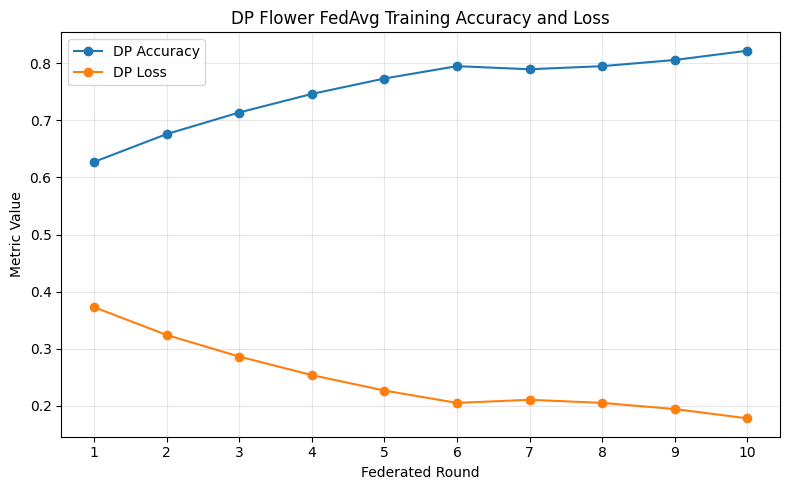

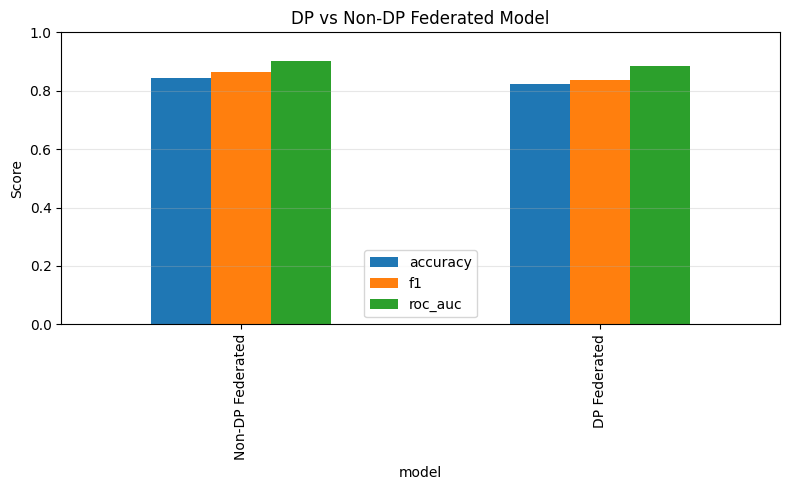

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(dp_history_df["round"], dp_history_df["accuracy"], marker="o", label="DP Accuracy")
plt.plot(dp_history_df["round"], dp_history_df["loss"], marker="o", label="DP Loss")
plt.xlabel("Federated Round")
plt.ylabel("Metric Value")
plt.title("DP Flower FedAvg Training Accuracy and Loss")
plt.xticks(dp_history_df["round"])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

if "comparison_df" in globals():
    comparison_df.set_index("model")[["accuracy", "f1", "roc_auc"]].plot(kind="bar", figsize=(8, 5))
    plt.title("DP vs Non-DP Federated Model")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()